In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\HP\Desktop\retailpulse_project\data\processed\cleaned_data.csv')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [2]:
df.shape
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='str')

In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['TotalPrice']
    .sum()
    .reset_index()
)

daily_sales.columns = ['Date', 'Demand']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

daily_sales.head()

,Date,Demand
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [6]:
daily_sales.shape

(305, 2)

In [8]:
daily_sales.head()

,Date,Demand
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [9]:
avg_demand = daily_sales['Demand'].mean()
std_demand = daily_sales['Demand'].std()

print("Average Daily Demand:", avg_demand)
print("Demand Standard Deviation:", std_demand)

Average Daily Demand: 29138.389816393446
Demand Standard Deviation: 17834.94734390911


In [10]:
lead_time = 7
z_score = 1.65

safety_stock = z_score * std_demand * np.sqrt(lead_time)

print("Safety Stock:", round(safety_stock, 2))

Safety Stock: 77858.28


In [11]:
# rop

reorder_point = (avg_demand * lead_time) + safety_stock

print("Reorder Point:", round(reorder_point, 2))

Reorder Point: 281827.01


In [13]:
# inventory recommendation ta ble

inventory_report = pd.DataFrame({
    'Metric': [
        'Average Daily Demand',
        'Demand Std Dev',
        'Safety Stock',
        'Reorder Point'
    ],
    'Value': [
        round(avg_demand, 2),
        round(std_demand, 2),
        round(safety_stock, 2),
        round(reorder_point, 2)
    ]
})

inventory_report

,Metric,Value
0,Average Daily Demand,29138.39
1,Demand Std Dev,17834.95
2,Safety Stock,77858.28
3,Reorder Point,281827.01


In [19]:
inventory_report.to_csv(
    "../data/processed/inventory_optimization_report.csv",
    index=False
)



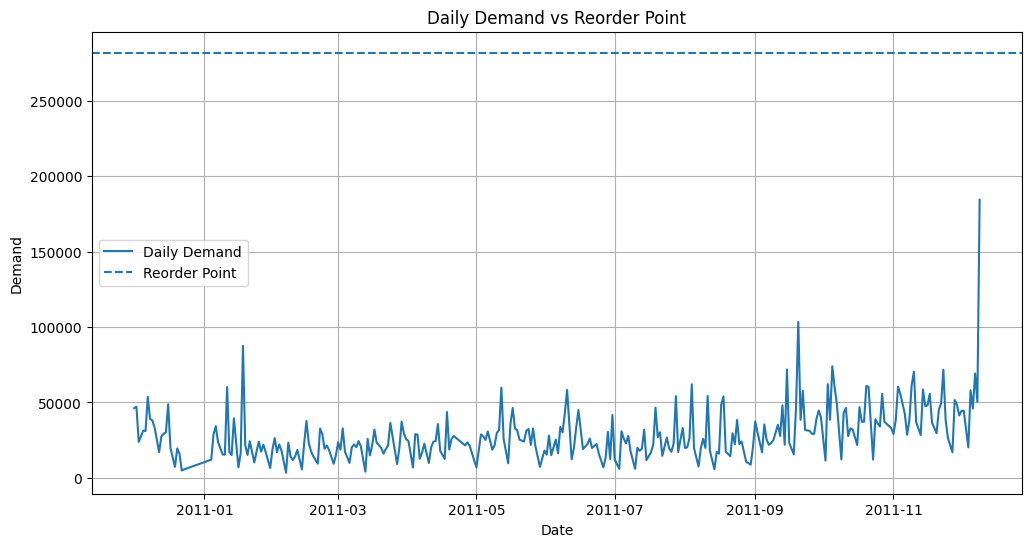

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_sales['Date'],
    daily_sales['Demand'],
    label='Daily Demand'
)

plt.axhline(
    y=reorder_point,
    linestyle='--',
    label='Reorder Point'
)

plt.title('Daily Demand vs Reorder Point')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)

plt.show()